In [1]:
import json
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import sys
import nltk
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
sys.path.append("..")

from solver.candidates import generate_candidates
from solver.scoring import score_all_candidates
from solver.search import greedy_solve, beam_solve, get_tau_estimate
from solver.lexical import add_lexical_scores
from solver.feedback import apply_feedback, simulate_feedback
from solver.evaluate import evaluate_prediction
from solver.categorize import classify_group, classify_all_puzzles

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Imports done")

Imports done


In [2]:
# ── Load labeled puzzles ─────────────────────────────────────────────
with open("../data/puzzles_labeled.json", "r") as f:
    puzzles = json.load(f)

# fix words from groups and remove emoji puzzle
for puzzle in puzzles:
    words_from_groups = []
    for group in puzzle["groups"]:
        words_from_groups.extend(group["members"])
    puzzle["words"] = words_from_groups
puzzles = [p for p in puzzles if p["puzzle_id"] != 295]

# ── Train/test split by date ─────────────────────────────────────────
puzzles_sorted = sorted(puzzles, key=lambda p: p["date"])
split_idx = int(len(puzzles_sorted) * 0.80)
train_puzzles = puzzles_sorted[:split_idx]
test_puzzles  = puzzles_sorted[split_idx:]

print(f"Total puzzles: {len(puzzles_sorted)}")
print(f"Train: {len(train_puzzles)} ({train_puzzles[0]['date']} to {train_puzzles[-1]['date']})")
print(f"Test:  {len(test_puzzles)} ({test_puzzles[0]['date']} to {test_puzzles[-1]['date']})")

Total puzzles: 226
Train: 180 (2023-10-16 to 2024-04-18)
Test:  46 (2024-04-19 to 2024-06-03)


In [3]:
# ── Load MPNet and compute embeddings ────────────────────────────────
print("Loading MPNet...")
model = SentenceTransformer("all-mpnet-base-v2")
print("Model loaded")

print("Computing embeddings...")
for puzzle in puzzles_sorted:
    embeddings = model.encode(puzzle["words"], show_progress_bar=False)
    puzzle["embeddings"] = embeddings

print(f"Embeddings computed for {len(puzzles_sorted)} puzzles")

Loading MPNet...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded
Computing embeddings...
Embeddings computed for 226 puzzles


In [15]:
# ── Precompute candidates for test and train puzzles ─────────────────
print("Precomputing test candidates...")
test_precomputed = []
for puzzle in test_puzzles:
    words = puzzle["words"]
    embeddings = np.array(puzzle["embeddings"])
    candidates = generate_candidates(words, embeddings)
    tau = get_tau_estimate(candidates)
    test_precomputed.append({
        "puzzle": puzzle,
        "candidates": candidates,
        "tau": tau
    })
print(f"Done — {len(test_precomputed)} test puzzles precomputed")

print("Precomputing train candidates...")
train_precomputed = []
for puzzle in train_puzzles:
    words = puzzle["words"]
    embeddings = np.array(puzzle["embeddings"])
    candidates = generate_candidates(words, embeddings)
    tau = get_tau_estimate(candidates)
    train_precomputed.append({
        "puzzle": puzzle,
        "candidates": candidates,
        "tau": tau
    })
print(f"Done — {len(train_precomputed)} train puzzles precomputed")

Precomputing test candidates...
Done — 46 test puzzles precomputed
Precomputing train candidates...
Done — 180 train puzzles precomputed


In [19]:
# ── Table: Beam width sweep (test set) ───────────────────────────
beam_widths = [5, 10, 15, 20, 25, 30, 40, 50, 75, 90, 100, 110, 125, 150]
beam_results = []

for B in beam_widths:
    solved, correct, top1 = [], [], []
    for item in train_precomputed:
        puzzle = item["puzzle"]
        candidates = copy.deepcopy(item["candidates"])
        tau = item["tau"]
        words = puzzle["words"]
        embeddings = np.array(puzzle["embeddings"])
        for c in candidates:
            c["score"] = c["cohesion"]
        predicted = beam_solve(words, embeddings, candidates, beam_width=B)
        result = evaluate_prediction(predicted, puzzle["groups"])
        solved.append(result["solved"])
        correct.append(result["n_correct"])
        top1.append(result["top1_correct"])
    beam_results.append({
        "B": B,
        "solve_rate": round(np.mean(solved), 3),
        "mean_correct": round(np.mean(correct), 3),
        "top1": round(np.mean(top1), 3)
    })
    print(f"B={B:4d} → solve_rate={np.mean(solved):.3f}  mean_correct={np.mean(correct):.3f}  top1={np.mean(top1):.3f}")

beam_df = pd.DataFrame(beam_results)
best_B = beam_df.loc[beam_df['solve_rate'].idxmax(), 'B']
print(f"\nBest B = {best_B}")
print(beam_df.to_string(index=False))

B=   5 → solve_rate=0.044  mean_correct=0.761  top1=0.256
B=  10 → solve_rate=0.044  mean_correct=0.783  top1=0.256
B=  15 → solve_rate=0.050  mean_correct=0.800  top1=0.250
B=  20 → solve_rate=0.056  mean_correct=0.817  top1=0.250
B=  25 → solve_rate=0.056  mean_correct=0.800  top1=0.239
B=  30 → solve_rate=0.050  mean_correct=0.783  top1=0.239
B=  40 → solve_rate=0.056  mean_correct=0.794  top1=0.256
B=  50 → solve_rate=0.061  mean_correct=0.806  top1=0.256
B=  75 → solve_rate=0.067  mean_correct=0.844  top1=0.278
B=  90 → solve_rate=0.067  mean_correct=0.839  top1=0.267
B= 100 → solve_rate=0.067  mean_correct=0.844  top1=0.267
B= 110 → solve_rate=0.067  mean_correct=0.844  top1=0.267
B= 125 → solve_rate=0.067  mean_correct=0.844  top1=0.267
B= 150 → solve_rate=0.067  mean_correct=0.844  top1=0.267

Best B = 75
  B  solve_rate  mean_correct  top1
  5       0.044         0.761 0.256
 10       0.044         0.783 0.256
 15       0.050         0.800 0.250
 20       0.056         0.817 0

In [21]:
# ── Table: S3 grid search on training set ────────────────────────
import itertools

betas  = [-0.10, -0.05, 0.0, 0.05, 0.10]
gammas = [-0.10, -0.05, 0.0, 0.05, 0.10]
grid_results = []

total = len(betas) * len(gammas)
print(f"Testing {total} combinations on training set...")

for b, g in itertools.product(betas, gammas):
    solved, correct, top1 = [], [], []
    for item in train_precomputed:
        puzzle = item["puzzle"]
        candidates = copy.deepcopy(item["candidates"])
        tau = item["tau"]
        words = puzzle["words"]
        embeddings = np.array(puzzle["embeddings"])
        candidates = score_all_candidates(candidates, tau, 1.0, b, g)
        predicted = beam_solve(words, embeddings, candidates, beam_width=75)
        result = evaluate_prediction(predicted, puzzle["groups"])
        solved.append(result["solved"])
        correct.append(result["n_correct"])
        top1.append(result["top1_correct"])
    grid_results.append({
        "beta": b, "gamma": g,
        "solve_rate": round(np.mean(solved), 3),
        "mean_correct": round(np.mean(correct), 3),
        "top1": round(np.mean(top1), 3)
    })
    print(f"  beta={b:.2f} gamma={g:.2f} → solve_rate={np.mean(solved):.3f}")

grid_df = pd.DataFrame(grid_results).sort_values("solve_rate", ascending=False)
best = grid_df.iloc[0]
print(f"\nBest: beta={best.beta}, gamma={best.gamma}, solve_rate={best.solve_rate}")
print(grid_df.to_string(index=False))

Testing 25 combinations on training set...
  beta=-0.10 gamma=-0.10 → solve_rate=0.022
  beta=-0.10 gamma=-0.05 → solve_rate=0.028
  beta=-0.10 gamma=0.00 → solve_rate=0.067
  beta=-0.10 gamma=0.05 → solve_rate=0.061
  beta=-0.10 gamma=0.10 → solve_rate=0.056
  beta=-0.05 gamma=-0.10 → solve_rate=0.022
  beta=-0.05 gamma=-0.05 → solve_rate=0.028
  beta=-0.05 gamma=0.00 → solve_rate=0.067
  beta=-0.05 gamma=0.05 → solve_rate=0.061
  beta=-0.05 gamma=0.10 → solve_rate=0.061
  beta=0.00 gamma=-0.10 → solve_rate=0.028
  beta=0.00 gamma=-0.05 → solve_rate=0.033
  beta=0.00 gamma=0.00 → solve_rate=0.067
  beta=0.00 gamma=0.05 → solve_rate=0.061
  beta=0.00 gamma=0.10 → solve_rate=0.061
  beta=0.05 gamma=-0.10 → solve_rate=0.028
  beta=0.05 gamma=-0.05 → solve_rate=0.033
  beta=0.05 gamma=0.00 → solve_rate=0.061
  beta=0.05 gamma=0.05 → solve_rate=0.056
  beta=0.05 gamma=0.10 → solve_rate=0.056
  beta=0.10 gamma=-0.10 → solve_rate=0.028
  beta=0.10 gamma=-0.05 → solve_rate=0.033
  beta=0.10 g

In [23]:
# ── Table: Eta sweep (training set) ──────────────────────────────
eta_values = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.75, 1.0]
eta_results = []

BEST_B = 75  # from beam sweep
BEST_BETA = 0.00
BEST_GAMMA = 0.00

for eta_val in eta_values:
    solved, correct, top1 = [], [], []
    for item in train_precomputed:
        puzzle = item["puzzle"]
        candidates = copy.deepcopy(item["candidates"])
        tau = item["tau"]
        words = puzzle["words"]
        embeddings = np.array(puzzle["embeddings"])
        candidates = score_all_candidates(candidates, tau, 1.0, BEST_BETA, BEST_GAMMA)
        candidates = add_lexical_scores(candidates)
        for c in candidates:
            c["score"] = c["score"] + eta_val * c["lexical"]
        candidates.sort(key=lambda x: x["score"], reverse=True)
        predicted = beam_solve(words, embeddings, candidates, beam_width=BEST_B)
        result = evaluate_prediction(predicted, puzzle["groups"])
        solved.append(result["solved"])
        correct.append(result["n_correct"])
        top1.append(result["top1_correct"])
    eta_results.append({
        "eta": eta_val,
        "solve_rate": round(np.mean(solved), 3),
        "mean_correct": round(np.mean(correct), 3),
        "top1": round(np.mean(top1), 3)
    })
    print(f"eta={eta_val:.2f} → solve_rate={np.mean(solved):.3f}  mean_correct={np.mean(correct):.3f}  top1={np.mean(top1):.3f}")

eta_df = pd.DataFrame(eta_results)
best_eta = eta_df.loc[eta_df['solve_rate'].idxmax(), 'eta']
print(f"\nBest eta = {best_eta}")
print(eta_df.to_string(index=False))

eta=0.00 → solve_rate=0.067  mean_correct=0.844  top1=0.278
eta=0.05 → solve_rate=0.089  mean_correct=1.000  top1=0.344
eta=0.10 → solve_rate=0.100  mean_correct=1.083  top1=0.378
eta=0.15 → solve_rate=0.100  mean_correct=1.072  top1=0.400
eta=0.20 → solve_rate=0.083  mean_correct=1.033  top1=0.417
eta=0.25 → solve_rate=0.089  mean_correct=1.028  top1=0.400
eta=0.30 → solve_rate=0.072  mean_correct=0.972  top1=0.389
eta=0.40 → solve_rate=0.067  mean_correct=0.906  top1=0.378
eta=0.50 → solve_rate=0.067  mean_correct=0.856  top1=0.350
eta=0.75 → solve_rate=0.050  mean_correct=0.794  top1=0.339
eta=1.00 → solve_rate=0.044  mean_correct=0.794  top1=0.339

Best eta = 0.1
 eta  solve_rate  mean_correct  top1
0.00       0.067         0.844 0.278
0.05       0.089         1.000 0.344
0.10       0.100         1.083 0.378
0.15       0.100         1.072 0.400
0.20       0.083         1.033 0.417
0.25       0.089         1.028 0.400
0.30       0.072         0.972 0.389
0.40       0.067         0.9

In [24]:
# ── Final best weights from training set sweeps ──────────────────────
ALPHA = 1.0    # cohesion weight (fixed)
BETA  = 0.0    # margin weight (grid search: no benefit)
GAMMA = 0.0    # false group penalty (grid search: no benefit)
ETA   = 0.10   # lexical weight (eta sweep: best on training)
BEAM  = 75     # beam width (beam sweep: best on training)

print("Final hyperparameters:")
print(f"  ALPHA = {ALPHA}")
print(f"  BETA  = {BETA}")
print(f"  GAMMA = {GAMMA}")
print(f"  ETA   = {ETA}")
print(f"  BEAM  = {BEAM}")

Final hyperparameters:
  ALPHA = 1.0
  BETA  = 0.0
  GAMMA = 0.0
  ETA   = 0.1
  BEAM  = 75


In [25]:
# ── One-away boost sweep (training set) ──────────────────────────────
boost_values = [1.0, 1.1, 1.2, 1.25, 1.5, 2.0, 2.5, 3.0]
boost_results = []

for boost in boost_values:
    solved, correct, top1 = [], [], []

    for item in train_precomputed:
        puzzle = item["puzzle"]
        true_groups = puzzle["groups"]
        remaining = list(puzzle["words"])
        solved_groups = []
        excluded_guesses = set()
        last_guess = None
        last_feedback = None

        for _ in range(7):
            if len(solved_groups) == 4:
                break
            if len(remaining) == 4:
                solved_groups.append(remaining)
                break

            remaining_embs = model.encode(remaining, show_progress_bar=False)
            candidates = generate_candidates(remaining, remaining_embs)
            candidates = [c for c in candidates if c["word_set"] not in excluded_guesses]
            if not candidates:
                break

            tau_current = get_tau_estimate(candidates)
            candidates = score_all_candidates(candidates, tau_current, ALPHA, BETA, GAMMA)
            candidates = add_lexical_scores(candidates)
            for c in candidates:
                c["score"] = c["score"] + ETA * c["lexical"]

            if last_feedback == "one_away" and last_guess is not None:
                last_set = frozenset(last_guess)
                for c in candidates:
                    if len(c["word_set"] & last_set) == 3:
                        c["score"] = c["score"] * boost

            candidates.sort(key=lambda x: x["score"], reverse=True)

            try:
                predicted = beam_solve(remaining, remaining_embs, candidates, beam_width=BEAM)
                if not predicted:
                    break
                guess = predicted[0]
            except Exception:
                break

            feedback = simulate_feedback(guess, true_groups)
            last_guess = guess
            last_feedback = feedback

            if feedback == "correct":
                solved_groups.append(guess)
                remaining = [w for w in remaining if w not in guess]
                excluded_guesses = set()
                last_guess = None
                last_feedback = None
            else:
                excluded_guesses.add(frozenset(guess))

        result = evaluate_prediction(solved_groups, true_groups)
        solved.append(result["solved"])
        correct.append(result["n_correct"])
        top1.append(result["top1_correct"])

    boost_results.append({
        "boost": boost,
        "solve_rate": round(np.mean(solved), 3),
        "mean_correct": round(np.mean(correct), 3),
        "top1": round(np.mean(top1), 3)
    })
    print(f"boost={boost:.2f} → solve_rate={np.mean(solved):.3f}  mean_correct={np.mean(correct):.3f}  top1={np.mean(top1):.3f}")

boost_df = pd.DataFrame(boost_results)
best_boost = boost_df.loc[boost_df['solve_rate'].idxmax(), 'boost']
print(f"\nBest boost = {best_boost}")
print(boost_df.to_string(index=False))

boost=1.00 → solve_rate=0.194  mean_correct=1.478  top1=0.672
boost=1.10 → solve_rate=0.217  mean_correct=1.556  top1=0.689
boost=1.20 → solve_rate=0.217  mean_correct=1.572  top1=0.689
boost=1.25 → solve_rate=0.228  mean_correct=1.600  top1=0.700
boost=1.50 → solve_rate=0.233  mean_correct=1.617  top1=0.717
boost=2.00 → solve_rate=0.217  mean_correct=1.589  top1=0.706
boost=2.50 → solve_rate=0.217  mean_correct=1.567  top1=0.706
boost=3.00 → solve_rate=0.222  mean_correct=1.561  top1=0.694

Best boost = 1.5
 boost  solve_rate  mean_correct  top1
  1.00       0.194         1.478 0.672
  1.10       0.217         1.556 0.689
  1.20       0.217         1.572 0.689
  1.25       0.228         1.600 0.700
  1.50       0.233         1.617 0.717
  2.00       0.217         1.589 0.706
  2.50       0.217         1.567 0.706
  3.00       0.222         1.561 0.694


In [26]:
# ── Final best weights from training set sweeps ──────────────────────
ALPHA = 1.0    # cohesion weight (fixed)
BETA  = 0.0    # margin weight (grid search: no benefit)
GAMMA = 0.0    # false group penalty (grid search: no benefit)
ETA   = 0.10   # lexical weight (eta sweep: best on training)
BEAM  = 75     # beam width (beam sweep: best on training)
BOOST = 1.5    # one-away boost (boost sweep: best on training)

print("Final hyperparameters:")
print(f"  ALPHA = {ALPHA}")
print(f"  BETA  = {BETA}")
print(f"  GAMMA = {GAMMA}")
print(f"  ETA   = {ETA}")
print(f"  BEAM  = {BEAM}")
print(f"  BOOST = {BOOST}")

Final hyperparameters:
  ALPHA = 1.0
  BETA  = 0.0
  GAMMA = 0.0
  ETA   = 0.1
  BEAM  = 75
  BOOST = 1.5


In [27]:
# ── S1: Greedy baseline ──────────────────────────────────────────────
print("Running S1: Greedy baseline...")
solved_s1, correct_s1, top1_s1 = [], [], []

for item in test_precomputed:
    puzzle = item["puzzle"]
    candidates = copy.deepcopy(item["candidates"])
    words = puzzle["words"]
    embeddings = np.array(puzzle["embeddings"])
    for c in candidates:
        c["score"] = c["cohesion"]
    predicted = greedy_solve(words, embeddings, candidates)
    result = evaluate_prediction(predicted, puzzle["groups"])
    solved_s1.append(result["solved"])
    correct_s1.append(result["n_correct"])
    top1_s1.append(result["top1_correct"])

print(f"S1 → solve_rate={np.mean(solved_s1):.3f}  mean_correct={np.mean(correct_s1):.3f}  top1={np.mean(top1_s1):.3f}")

Running S1: Greedy baseline...
S1 → solve_rate=0.000  mean_correct=0.457  top1=0.217


In [28]:
# ── S2: Beam search ──────────────────────────────────────────────────
print("Running S2: Beam search...")
solved_s2, correct_s2, top1_s2 = [], [], []

for item in test_precomputed:
    puzzle = item["puzzle"]
    candidates = copy.deepcopy(item["candidates"])
    words = puzzle["words"]
    embeddings = np.array(puzzle["embeddings"])
    for c in candidates:
        c["score"] = c["cohesion"]
    predicted = beam_solve(words, embeddings, candidates, beam_width=BEAM)
    result = evaluate_prediction(predicted, puzzle["groups"])
    solved_s2.append(result["solved"])
    correct_s2.append(result["n_correct"])
    top1_s2.append(result["top1_correct"])

print(f"S2 → solve_rate={np.mean(solved_s2):.3f}  mean_correct={np.mean(correct_s2):.3f}  top1={np.mean(top1_s2):.3f}")

Running S2: Beam search...
S2 → solve_rate=0.043  mean_correct=0.652  top1=0.261


In [29]:
# ── S3: Beam + false group penalty ───────────────────────────────────
print("Running S3: Beam + false group penalty...")
solved_s3, correct_s3, top1_s3 = [], [], []

for item in test_precomputed:
    puzzle = item["puzzle"]
    candidates = copy.deepcopy(item["candidates"])
    tau = item["tau"]
    words = puzzle["words"]
    embeddings = np.array(puzzle["embeddings"])
    candidates = score_all_candidates(candidates, tau, ALPHA, BETA, GAMMA)
    predicted = beam_solve(words, embeddings, candidates, beam_width=BEAM)
    result = evaluate_prediction(predicted, puzzle["groups"])
    solved_s3.append(result["solved"])
    correct_s3.append(result["n_correct"])
    top1_s3.append(result["top1_correct"])

print(f"S3 → solve_rate={np.mean(solved_s3):.3f}  mean_correct={np.mean(correct_s3):.3f}  top1={np.mean(top1_s3):.3f}")

Running S3: Beam + false group penalty...
S3 → solve_rate=0.043  mean_correct=0.652  top1=0.261


In [30]:
# ── S4: Beam + lexical augmentation ──────────────────────────────────
print("Running S4: Beam + lexical augmentation...")
solved_s4, correct_s4, top1_s4 = [], [], []

for item in test_precomputed:
    puzzle = item["puzzle"]
    candidates = copy.deepcopy(item["candidates"])
    tau = item["tau"]
    words = puzzle["words"]
    embeddings = np.array(puzzle["embeddings"])
    candidates = score_all_candidates(candidates, tau, ALPHA, BETA, GAMMA)
    candidates = add_lexical_scores(candidates)
    for c in candidates:
        c["score"] = c["score"] + ETA * c["lexical"]
    candidates.sort(key=lambda x: x["score"], reverse=True)
    predicted = beam_solve(words, embeddings, candidates, beam_width=BEAM)
    result = evaluate_prediction(predicted, puzzle["groups"])
    solved_s4.append(result["solved"])
    correct_s4.append(result["n_correct"])
    top1_s4.append(result["top1_correct"])

print(f"S4 → solve_rate={np.mean(solved_s4):.3f}  mean_correct={np.mean(correct_s4):.3f}  top1={np.mean(top1_s4):.3f}")

Running S4: Beam + lexical augmentation...
S4 → solve_rate=0.065  mean_correct=0.826  top1=0.283


In [31]:
# ── S5: Full pipeline + feedback ─────────────────────────────────────
print("Running S5: Full pipeline + feedback...")
solved_s5, correct_s5, top1_s5 = [], [], []

for item in test_precomputed:
    puzzle = item["puzzle"]
    true_groups = puzzle["groups"]
    remaining = list(puzzle["words"])
    solved_groups = []
    excluded_guesses = set()
    last_guess = None
    last_feedback = None

    for _ in range(7):
        if len(solved_groups) == 4:
            break
        if len(remaining) == 4:
            solved_groups.append(remaining)
            break

        remaining_embs = model.encode(remaining, show_progress_bar=False)
        candidates = generate_candidates(remaining, remaining_embs)
        candidates = [c for c in candidates if c["word_set"] not in excluded_guesses]
        if not candidates:
            break

        tau_current = get_tau_estimate(candidates)
        candidates = score_all_candidates(candidates, tau_current, ALPHA, BETA, GAMMA)
        candidates = add_lexical_scores(candidates)
        for c in candidates:
            c["score"] = c["score"] + ETA * c["lexical"]

        if last_feedback == "one_away" and last_guess is not None:
            last_set = frozenset(last_guess)
            for c in candidates:
                if len(c["word_set"] & last_set) == 3:
                    c["score"] = c["score"] * BOOST

        candidates.sort(key=lambda x: x["score"], reverse=True)

        try:
            predicted = beam_solve(remaining, remaining_embs, candidates, beam_width=BEAM)
            if not predicted:
                break
            guess = predicted[0]
        except Exception:
            break

        feedback = simulate_feedback(guess, true_groups)
        last_guess = guess
        last_feedback = feedback

        if feedback == "correct":
            solved_groups.append(guess)
            remaining = [w for w in remaining if w not in guess]
            excluded_guesses = set()
            last_guess = None
            last_feedback = None
        else:
            excluded_guesses.add(frozenset(guess))

    result = evaluate_prediction(solved_groups, true_groups)
    solved_s5.append(result["solved"])
    correct_s5.append(result["n_correct"])
    top1_s5.append(result["top1_correct"])

print(f"S5 → solve_rate={np.mean(solved_s5):.3f}  mean_correct={np.mean(correct_s5):.3f}  top1={np.mean(top1_s5):.3f}")

Running S5: Full pipeline + feedback...
S5 → solve_rate=0.152  mean_correct=1.196  top1=0.565


In [32]:
# ── Final ablation results table ─────────────────────────────────────
results_summary = pd.DataFrame([
    {
        "Solver": "S1: Greedy",
        "Solve Rate": np.mean(solved_s1),
        "Mean Correct Groups": np.mean(correct_s1),
        "Top-1 Accuracy": np.mean(top1_s1)
    },
    {
        "Solver": "S2: Beam Search (B=75)",
        "Solve Rate": np.mean(solved_s2),
        "Mean Correct Groups": np.mean(correct_s2),
        "Top-1 Accuracy": np.mean(top1_s2)
    },
    {
        "Solver": "S3: Beam + Penalty",
        "Solve Rate": np.mean(solved_s3),
        "Mean Correct Groups": np.mean(correct_s3),
        "Top-1 Accuracy": np.mean(top1_s3)
    },
    {
        "Solver": "S4: Beam + Lexical (η=0.10)",
        "Solve Rate": np.mean(solved_s4),
        "Mean Correct Groups": np.mean(correct_s4),
        "Top-1 Accuracy": np.mean(top1_s4)
    },
    {
        "Solver": "S5: Full Pipeline + Feedback",
        "Solve Rate": np.mean(solved_s5),
        "Mean Correct Groups": np.mean(correct_s5),
        "Top-1 Accuracy": np.mean(top1_s5)
    }
])

print(results_summary.round(3).to_string(index=False))

                      Solver  Solve Rate  Mean Correct Groups  Top-1 Accuracy
                  S1: Greedy       0.000                0.457           0.217
      S2: Beam Search (B=75)       0.043                0.652           0.261
          S3: Beam + Penalty       0.043                0.652           0.261
 S4: Beam + Lexical (η=0.10)       0.065                0.826           0.283
S5: Full Pipeline + Feedback       0.152                1.196           0.565


In [33]:
# ── Load group classifications ────────────────────────────────────────
with open("../data/group_classifications.json", "r") as f:
    classifications = json.load(f)

cat_lookup = {}
for key, val in classifications.items():
    cat_lookup[(val["puzzle_id"], val["level"])] = val["category"]

CATEGORIES = ["SEMANTIC", "ENCYCLOPEDIC", "WORDPLAY", "ASSOCIATIVE"]

def get_category_accuracy(predicted_groups_list, test_precomputed):
    """Given a list of predicted groups per puzzle, compute per-category accuracy."""
    results = {cat: [] for cat in CATEGORIES}
    for i, item in enumerate(test_precomputed):
        puzzle = item["puzzle"]
        true_groups = puzzle["groups"]
        pred_sets = [frozenset(g) for g in predicted_groups_list[i]]
        for group in true_groups:
            level = group["level"]
            true_set = frozenset(group["members"])
            cat = cat_lookup.get((puzzle["puzzle_id"], level), "ASSOCIATIVE")
            results[cat].append(true_set in pred_sets)
    return {cat: np.mean(v) if v else 0 for cat, v in results.items()}

# collect all predictions
preds_s1, preds_s2, preds_s3, preds_s4 = [], [], [], []

for item in test_precomputed:
    puzzle = item["puzzle"]
    words = puzzle["words"]
    embeddings = np.array(puzzle["embeddings"])

    # S1
    c1 = copy.deepcopy(item["candidates"])
    for c in c1: c["score"] = c["cohesion"]
    preds_s1.append(greedy_solve(words, embeddings, c1))

    # S2
    c2 = copy.deepcopy(item["candidates"])
    for c in c2: c["score"] = c["cohesion"]
    preds_s2.append(beam_solve(words, embeddings, c2, beam_width=BEAM))

    # S3
    c3 = copy.deepcopy(item["candidates"])
    tau = item["tau"]
    c3 = score_all_candidates(c3, tau, ALPHA, BETA, GAMMA)
    preds_s3.append(beam_solve(words, embeddings, c3, beam_width=BEAM))

    # S4
    c4 = copy.deepcopy(item["candidates"])
    c4 = score_all_candidates(c4, tau, ALPHA, BETA, GAMMA)
    c4 = add_lexical_scores(c4)
    for c in c4: c["score"] = c["score"] + ETA * c["lexical"]
    c4.sort(key=lambda x: x["score"], reverse=True)
    preds_s4.append(beam_solve(words, embeddings, c4, beam_width=BEAM))

# S5 predictions from stored results
preds_s5 = []
for i, item in enumerate(test_precomputed):
    puzzle = item["puzzle"]
    true_groups = puzzle["groups"]
    remaining = list(puzzle["words"])
    solved_groups = []
    excluded_guesses = set()
    last_guess = None
    last_feedback = None

    for _ in range(7):
        if len(solved_groups) == 4:
            break
        if len(remaining) == 4:
            solved_groups.append(remaining)
            break
        remaining_embs = model.encode(remaining, show_progress_bar=False)
        candidates = generate_candidates(remaining, remaining_embs)
        candidates = [c for c in candidates if c["word_set"] not in excluded_guesses]
        if not candidates:
            break
        tau_current = get_tau_estimate(candidates)
        candidates = score_all_candidates(candidates, tau_current, ALPHA, BETA, GAMMA)
        candidates = add_lexical_scores(candidates)
        for c in candidates:
            c["score"] = c["score"] + ETA * c["lexical"]
        if last_feedback == "one_away" and last_guess is not None:
            last_set = frozenset(last_guess)
            for c in candidates:
                if len(c["word_set"] & last_set) == 3:
                    c["score"] = c["score"] * BOOST
        candidates.sort(key=lambda x: x["score"], reverse=True)
        try:
            predicted = beam_solve(remaining, remaining_embs, candidates, beam_width=BEAM)
            if not predicted:
                break
            guess = predicted[0]
        except Exception:
            break
        feedback = simulate_feedback(guess, true_groups)
        last_guess = guess
        last_feedback = feedback
        if feedback == "correct":
            solved_groups.append(guess)
            remaining = [w for w in remaining if w not in guess]
            excluded_guesses = set()
            last_guess = None
            last_feedback = None
        else:
            excluded_guesses.add(frozenset(guess))

    preds_s5.append(solved_groups)

# compute category accuracy for all solvers
acc_s1 = get_category_accuracy(preds_s1, test_precomputed)
acc_s2 = get_category_accuracy(preds_s2, test_precomputed)
acc_s3 = get_category_accuracy(preds_s3, test_precomputed)
acc_s4 = get_category_accuracy(preds_s4, test_precomputed)
acc_s5 = get_category_accuracy(preds_s5, test_precomputed)

print("Group-level accuracy by category:")
print(f"{'Category':<15} {'S1':>6} {'S2':>6} {'S3':>6} {'S4':>6} {'S5':>6}")
for cat in CATEGORIES:
    print(f"{cat:<15} {acc_s1[cat]:>6.3f} {acc_s2[cat]:>6.3f} {acc_s3[cat]:>6.3f} {acc_s4[cat]:>6.3f} {acc_s5[cat]:>6.3f}")

Group-level accuracy by category:
Category            S1     S2     S3     S4     S5
SEMANTIC         0.160  0.223  0.223  0.309  0.426
ENCYCLOPEDIC     0.036  0.036  0.036  0.036  0.179
WORDPLAY         0.000  0.026  0.026  0.053  0.132
ASSOCIATIVE      0.208  0.292  0.292  0.250  0.208


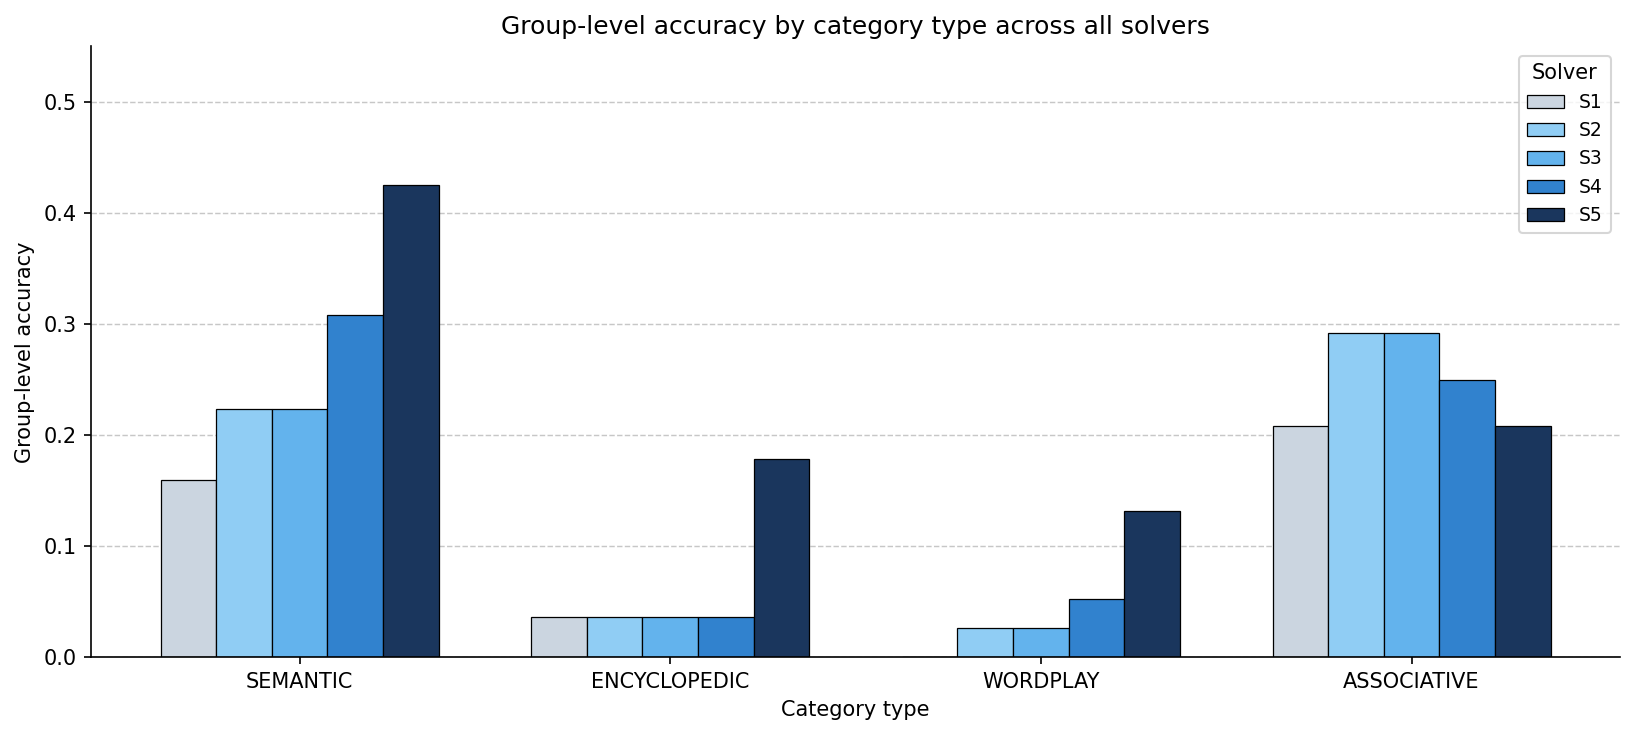

In [34]:
# ── Figure: All 5 solvers by category ────────────────────────────────
solver_names = ["S1", "S2", "S3", "S4", "S5"]
solver_accs = [acc_s1, acc_s2, acc_s3, acc_s4, acc_s5]
solver_colors = ["#CBD5E0", "#90CDF4", "#63B3ED", "#3182CE", "#1A365D"]

x = np.arange(len(CATEGORIES))
n_solvers = len(solver_names)
width = 0.15
offsets = np.linspace(-(n_solvers-1)/2, (n_solvers-1)/2, n_solvers) * width

fig, ax = plt.subplots(figsize=(11, 5))

for i, (name, accs, color) in enumerate(zip(solver_names, solver_accs, solver_colors)):
    values = [accs[cat] for cat in CATEGORIES]
    bars = ax.bar(x + offsets[i], values, width,
                  label=name, color=color, edgecolor="black", linewidth=0.6)

ax.set_xlabel("Category type")
ax.set_ylabel("Group-level accuracy")
ax.set_title("Group-level accuracy by category type across all solvers", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(CATEGORIES)
ax.legend(title="Solver", fontsize=9)
ax.set_ylim(0, 0.55)
ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../results/fig_category_all_solvers.png", dpi=150, bbox_inches="tight")
plt.show()

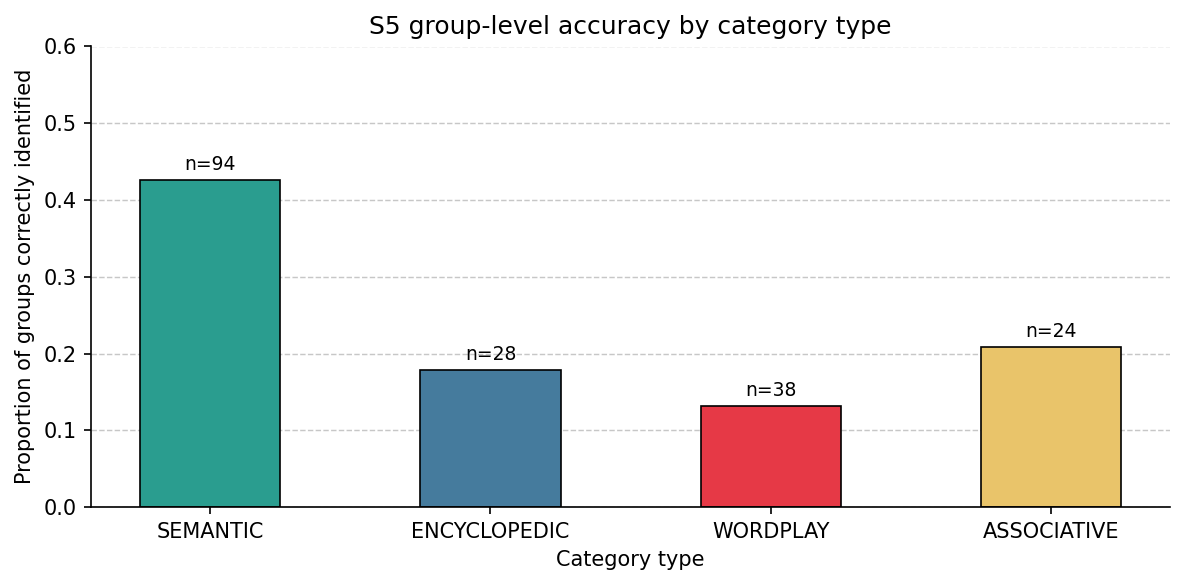

In [37]:
# ── Figure: S5 accuracy by category ──────────────────────────────────
cat_colors = ["#2A9D8F", "#457B9D", "#E63946", "#E9C46A"]

values_s5 = [acc_s5[cat] for cat in CATEGORIES]
counts = [len([1 for item in test_precomputed 
               for g in item["puzzle"]["groups"] 
               if cat_lookup.get((item["puzzle"]["puzzle_id"], g["level"]), "ASSOCIATIVE") == cat]) 
          for cat in CATEGORIES]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(CATEGORIES, values_s5, color=cat_colors,
              edgecolor="black", linewidth=0.8, width=0.5)

for bar, count, val in zip(bars, counts, values_s5):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f"n={count}", ha="center", va="bottom", fontsize=9, color="black")


ax.set_title("S5 group-level accuracy by category type", fontsize=12)
ax.set_xlabel("Category type")
ax.set_ylabel("Proportion of groups correctly identified")
ax.set_ylim(0, 0.6)
ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../results/fig_s5_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

        quartile   n   s1        s2        s3        s4        s5
0  Q1\n(easiest)  13  0.0  0.000000  0.000000  0.076923  0.230769
1             Q2  13  0.0  0.076923  0.076923  0.076923  0.153846
2             Q3   8  0.0  0.000000  0.000000  0.000000  0.125000
3  Q4\n(hardest)  12  0.0  0.083333  0.083333  0.083333  0.083333


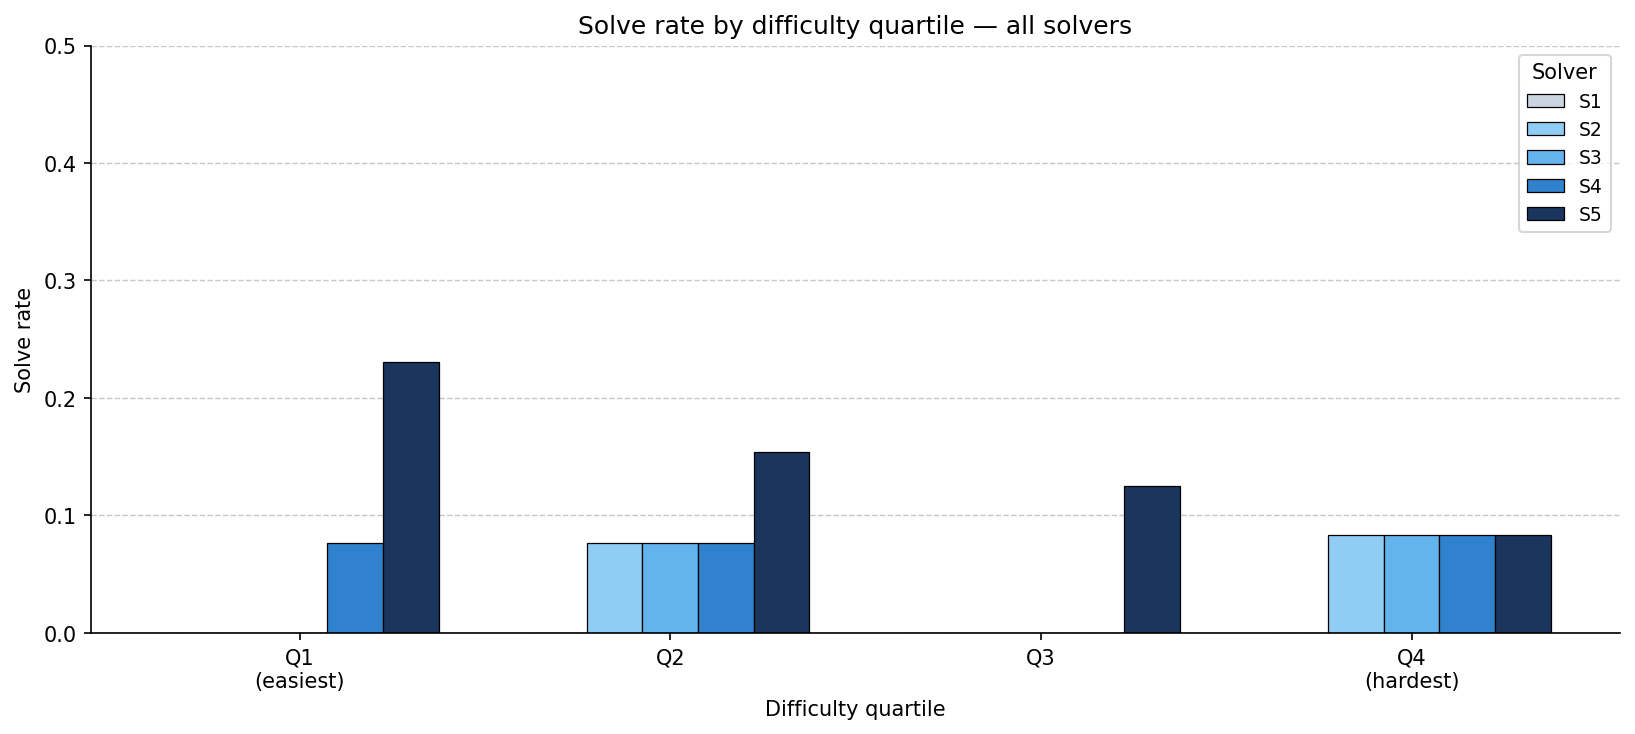

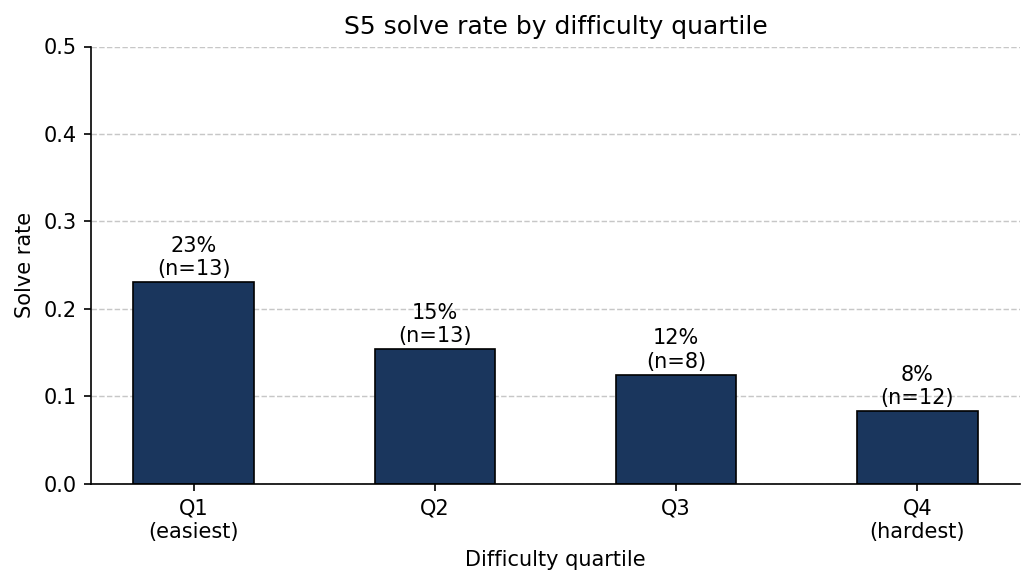

In [39]:
# ── Figure: Solve rate by difficulty quartile — all solvers + S5 only ─
difficulties = [item["puzzle"]["difficulty"] for item in test_precomputed]
df_test = pd.DataFrame({
    "difficulty": difficulties,
    "solved_s1": solved_s1,
    "solved_s2": solved_s2,
    "solved_s3": solved_s3,
    "solved_s4": solved_s4,
    "solved_s5": solved_s5,
})

df_test["quartile"] = pd.qcut(df_test["difficulty"], q=4,
                               labels=["Q1\n(easiest)", "Q2", "Q3", "Q4\n(hardest)"])

quartile_stats = df_test.groupby("quartile", observed=True).agg(
    n=("solved_s5", "count"),
    s1=("solved_s1", "mean"),
    s2=("solved_s2", "mean"),
    s3=("solved_s3", "mean"),
    s4=("solved_s4", "mean"),
    s5=("solved_s5", "mean"),
).reset_index()

print(quartile_stats)

x = np.arange(len(quartile_stats))
n_solvers = 5
width = 0.15
offsets = np.linspace(-(n_solvers-1)/2, (n_solvers-1)/2, n_solvers) * width
solver_cols = ["s1", "s2", "s3", "s4", "s5"]
solver_labels = ["S1", "S2", "S3", "S4", "S5"]
solver_colors = ["#CBD5E0", "#90CDF4", "#63B3ED", "#3182CE", "#1A365D"]

# ── Plot 1: All solvers ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
for i, (col, label, color) in enumerate(zip(solver_cols, solver_labels, solver_colors)):
    ax.bar(x + offsets[i], quartile_stats[col], width,
           label=label, color=color, edgecolor="black", linewidth=0.6)

ax.set_xticks(x)
ax.set_xticklabels(quartile_stats["quartile"])
ax.set_xlabel("Difficulty quartile")
ax.set_ylabel("Solve rate")
ax.set_title("Solve rate by difficulty quartile — all solvers", fontsize=12)
ax.legend(title="Solver", fontsize=9)
ax.set_ylim(0, 0.5)
ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("../results/fig_solve_rate_quartile_all.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: S5 only ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(x, quartile_stats["s5"], color="#1A365D",
              edgecolor="black", linewidth=0.8, width=0.5)

for bar, (_, row) in zip(bars, quartile_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f"{row['s5']:.0%}\n(n={int(row['n'])})",
            ha="center", fontsize=10, color="black")

ax.set_xticks(x)
ax.set_xticklabels(quartile_stats["quartile"])
ax.set_xlabel("Difficulty quartile")
ax.set_ylabel("Solve rate")
ax.set_title("S5 solve rate by difficulty quartile", fontsize=12)
ax.set_ylim(0, 0.5)
ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("../results/fig_solve_rate_quartile_s5.png", dpi=150, bbox_inches="tight")
plt.show()

Solved puzzles: 7
Mean guesses to solve: 5.29
Guess distribution for solved puzzles:
n_guesses
4    3
5    1
6    1
7    2
Name: count, dtype: int64


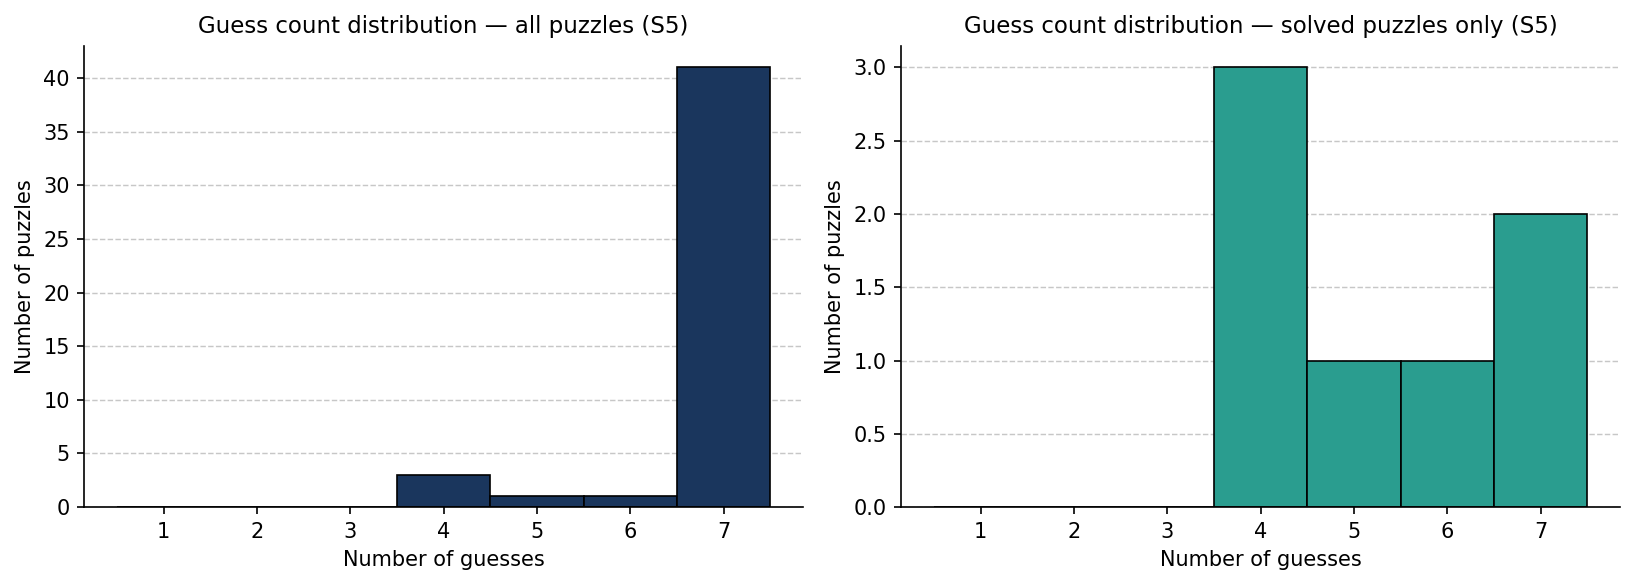

In [40]:
# ── Figure: Number of guesses distribution for S5 ────────────────────
guess_counts = []

for item in test_precomputed:
    puzzle = item["puzzle"]
    true_groups = puzzle["groups"]
    remaining = list(puzzle["words"])
    solved_groups = []
    excluded_guesses = set()
    last_guess = None
    last_feedback = None
    n_guesses = 0

    for _ in range(7):
        if len(solved_groups) == 4:
            break
        if len(remaining) == 4:
            solved_groups.append(remaining)
            n_guesses += 1
            break

        remaining_embs = model.encode(remaining, show_progress_bar=False)
        candidates = generate_candidates(remaining, remaining_embs)
        candidates = [c for c in candidates if c["word_set"] not in excluded_guesses]
        if not candidates:
            break

        tau_current = get_tau_estimate(candidates)
        candidates = score_all_candidates(candidates, tau_current, ALPHA, BETA, GAMMA)
        candidates = add_lexical_scores(candidates)
        for c in candidates:
            c["score"] = c["score"] + ETA * c["lexical"]
        if last_feedback == "one_away" and last_guess is not None:
            last_set = frozenset(last_guess)
            for c in candidates:
                if len(c["word_set"] & last_set) == 3:
                    c["score"] = c["score"] * BOOST
        candidates.sort(key=lambda x: x["score"], reverse=True)

        try:
            predicted = beam_solve(remaining, remaining_embs, candidates, beam_width=BEAM)
            if not predicted:
                break
            guess = predicted[0]
        except Exception:
            break

        n_guesses += 1
        feedback = simulate_feedback(guess, true_groups)
        last_guess = guess
        last_feedback = feedback

        if feedback == "correct":
            solved_groups.append(guess)
            remaining = [w for w in remaining if w not in guess]
            excluded_guesses = set()
            last_guess = None
            last_feedback = None
        else:
            excluded_guesses.add(frozenset(guess))

    guess_counts.append({
        "n_guesses": n_guesses,
        "solved": len(solved_groups) == 4,
        "n_correct": len(solved_groups)
    })

guess_df = pd.DataFrame(guess_counts)
solved_puzzles = guess_df[guess_df["solved"]]
print(f"Solved puzzles: {len(solved_puzzles)}")
print(f"Mean guesses to solve: {solved_puzzles['n_guesses'].mean():.2f}")
print(f"Guess distribution for solved puzzles:")
print(solved_puzzles["n_guesses"].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# left — all puzzles
axes[0].hist(guess_df["n_guesses"], bins=range(1, 9),
             color="#1A365D", edgecolor="black", linewidth=0.8, align="left")
axes[0].set_xlabel("Number of guesses")
axes[0].set_ylabel("Number of puzzles")
axes[0].set_title("Guess count distribution — all puzzles (S5)", fontsize=11)
axes[0].yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
axes[0].set_axisbelow(True)

# right — solved only
if len(solved_puzzles) > 0:
    axes[1].hist(solved_puzzles["n_guesses"], bins=range(1, 9),
                 color="#2A9D8F", edgecolor="black", linewidth=0.8, align="left")
    axes[1].set_xlabel("Number of guesses")
    axes[1].set_ylabel("Number of puzzles")
    axes[1].set_title("Guess count distribution — solved puzzles only (S5)", fontsize=11)
    axes[1].yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
    axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig("../results/fig_guess_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Computing false group stats for test puzzles...
Done — 46 puzzles
Puzzles with false groups: 22

Solve rate with false groups:    0.227
Solve rate without false groups: 0.083


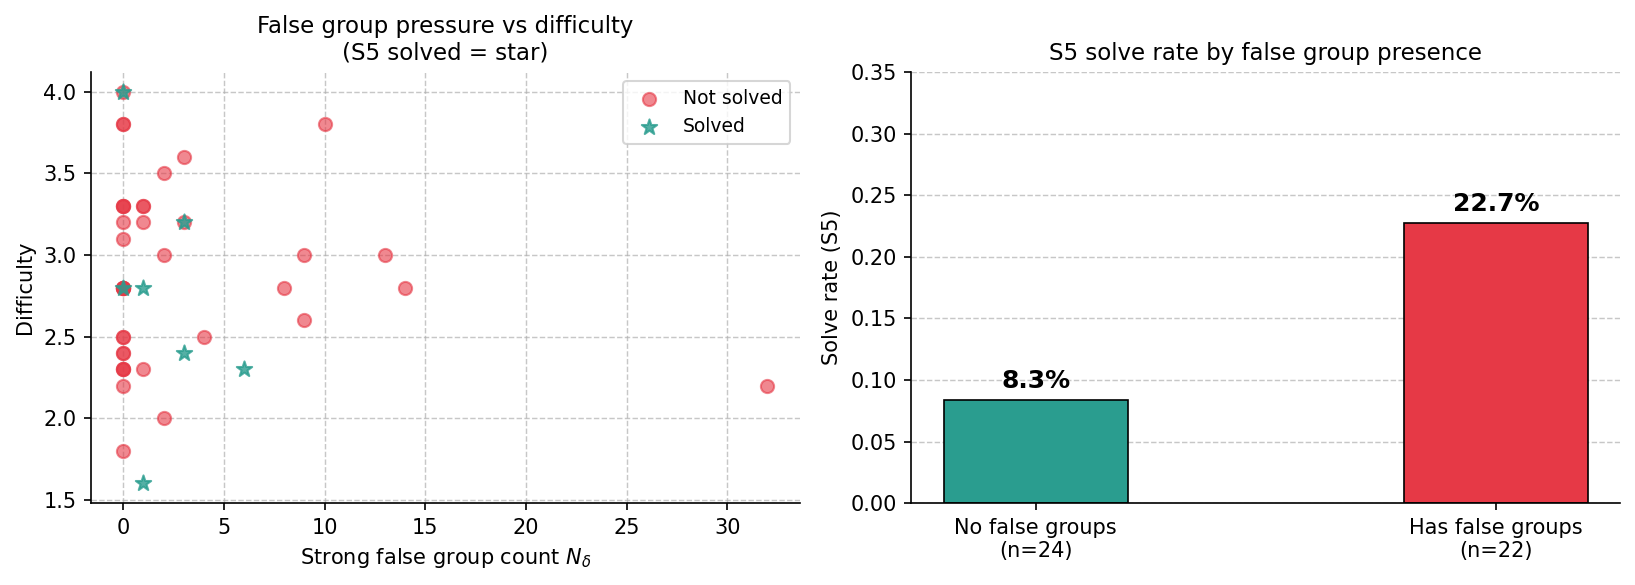

In [41]:
# ── Figure: False group pressure vs solver failure ────────────────────
from itertools import combinations as combs

def compute_false_group_stats(puzzle, delta=0.20):
    words = puzzle["words"]
    emb_array = np.array(puzzle["embeddings"])
    word_to_emb = {w: emb_array[i] for i, w in enumerate(words)}
    true_groups = [frozenset(g["members"]) for g in puzzle["groups"]]
    
    true_cohesions = []
    for g in puzzle["groups"]:
        embs = np.array([word_to_emb[w] for w in g["members"]])
        sims = cosine_similarity(embs)
        n = len(embs)
        c = sum(sims[i][j] for i in range(n) for j in range(i+1, n)) / (n*(n-1)/2)
        true_cohesions.append(c)
    tau = min(true_cohesions)
    
    n_false = 0
    best_gap = 0.0
    for combo in combs(words, 4):
        s = frozenset(combo)
        if s in true_groups:
            continue
        embs = np.array([word_to_emb[w] for w in combo])
        sims = cosine_similarity(embs)
        n = len(embs)
        c = sum(sims[i][j] for i in range(n) for j in range(i+1, n)) / (n*(n-1)/2)
        if c >= tau + delta:
            n_false += 1
            best_gap = max(best_gap, c - tau)
    
    return {"n_false": n_false, "best_gap": best_gap, "tau": tau}

print("Computing false group stats for test puzzles...")
false_stats = []
for i, item in enumerate(test_precomputed):
    stats = compute_false_group_stats(item["puzzle"])
    stats["solved_s5"] = solved_s5[i]
    stats["puzzle_id"] = item["puzzle"]["puzzle_id"]
    stats["difficulty"] = item["puzzle"]["difficulty"]
    false_stats.append(stats)

false_df = pd.DataFrame(false_stats)
print(f"Done — {len(false_df)} puzzles")
print(f"Puzzles with false groups: {(false_df['n_false'] > 0).sum()}")
print(f"\nSolve rate with false groups:    {false_df[false_df['n_false'] > 0]['solved_s5'].mean():.3f}")
print(f"Solve rate without false groups: {false_df[false_df['n_false'] == 0]['solved_s5'].mean():.3f}")

# ── Plot 1: N_delta vs solved/unsolved ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

solved_mask = false_df["solved_s5"].astype(bool)
axes[0].scatter(false_df[~solved_mask]["n_false"],
                false_df[~solved_mask]["difficulty"],
                color="#E63946", alpha=0.6, s=40, label="Not solved")
axes[0].scatter(false_df[solved_mask]["n_false"],
                false_df[solved_mask]["difficulty"],
                color="#2A9D8F", alpha=0.8, s=60, marker="*", label="Solved")
axes[0].set_xlabel("Strong false group count $N_\\delta$")
axes[0].set_ylabel("Difficulty")
axes[0].set_title("False group pressure vs difficulty\n(S5 solved = star)", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
axes[0].xaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
axes[0].set_axisbelow(True)

# ── Plot 2: Solve rate by false group presence ────────────────────────
categories_fg = ["No false groups\n(n={})".format((false_df["n_false"]==0).sum()),
                 "Has false groups\n(n={})".format((false_df["n_false"]>0).sum())]
solve_rates_fg = [
    false_df[false_df["n_false"]==0]["solved_s5"].mean(),
    false_df[false_df["n_false"]>0]["solved_s5"].mean()
]

axes[1].bar(categories_fg, solve_rates_fg,
            color=["#2A9D8F", "#E63946"], edgecolor="black", linewidth=0.8, width=0.4)
for i, val in enumerate(solve_rates_fg):
    axes[1].text(i, val + 0.01, f"{val:.1%}", ha="center", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Solve rate (S5)")
axes[1].set_title("S5 solve rate by false group presence", fontsize=11)
axes[1].set_ylim(0, 0.35)
axes[1].yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig("../results/fig_false_group_vs_solver.png", dpi=150, bbox_inches="tight")
plt.show()

Total groups solved: 55

Groups solved by color:
color
yellow    20
green     15
blue      13
purple     7
Name: count, dtype: int64

Mean solve position by color:
color
blue      2.0
green     1.6
purple    4.0
yellow    1.4
Name: solve_position, dtype: float64


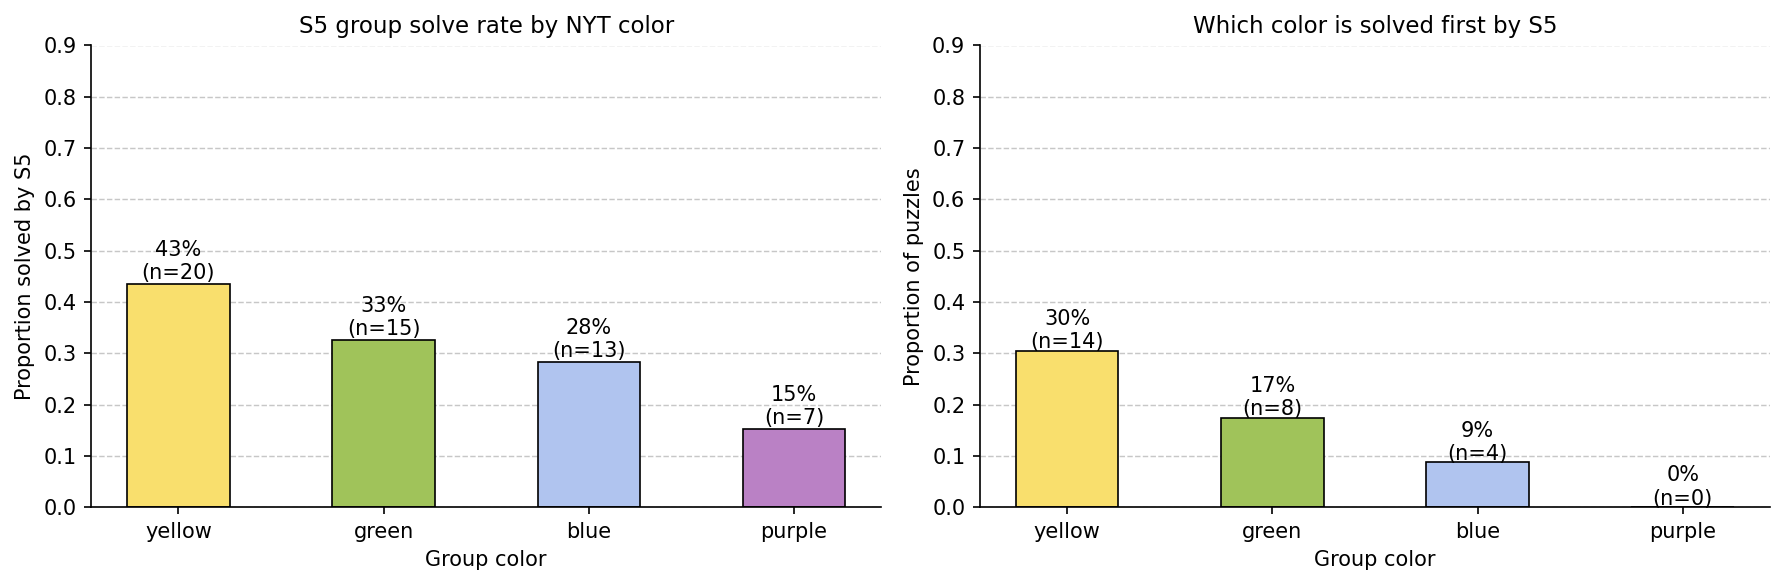

In [43]:
# ── Figure: Which color levels get solved and in what order ───────────
level_to_color = {0: "yellow", 1: "green", 2: "blue", 3: "purple"}
color_hex = {"yellow": "#F9DF6D", "green": "#A0C35A", 
             "blue": "#B0C4EF", "purple": "#BA81C5"}

solve_order_records = []

for item in test_precomputed:
    puzzle = item["puzzle"]
    true_groups = puzzle["groups"]
    remaining = list(puzzle["words"])
    solved_groups = []
    excluded_guesses = set()
    last_guess = None
    last_feedback = None
    guess_num = 0

    for _ in range(7):
        if len(solved_groups) == 4:
            break
        if len(remaining) == 4:
            # find which true group these remaining words belong to
            remaining_set = frozenset(remaining)
            for g in true_groups:
                if frozenset(g["members"]) == remaining_set:
                    solve_order_records.append({
                        "puzzle_id": puzzle["puzzle_id"],
                        "level": g["level"],
                        "color": level_to_color[g["level"]],
                        "solve_position": len(solved_groups) + 1,
                        "guess_number": guess_num + 1
                    })
            solved_groups.append((remaining, guess_num + 1))
            break

        remaining_embs = model.encode(remaining, show_progress_bar=False)
        candidates = generate_candidates(remaining, remaining_embs)
        candidates = [c for c in candidates if c["word_set"] not in excluded_guesses]
        if not candidates:
            break

        tau_current = get_tau_estimate(candidates)
        candidates = score_all_candidates(candidates, tau_current, ALPHA, BETA, GAMMA)
        candidates = add_lexical_scores(candidates)
        for c in candidates:
            c["score"] = c["score"] + ETA * c["lexical"]
        if last_feedback == "one_away" and last_guess is not None:
            last_set = frozenset(last_guess)
            for c in candidates:
                if len(c["word_set"] & last_set) == 3:
                    c["score"] = c["score"] * BOOST
        candidates.sort(key=lambda x: x["score"], reverse=True)

        try:
            predicted = beam_solve(remaining, remaining_embs, candidates, beam_width=BEAM)
            if not predicted:
                break
            guess = predicted[0]
        except Exception:
            break

        guess_num += 1
        feedback = simulate_feedback(guess, true_groups)
        last_guess = guess
        last_feedback = feedback

        if feedback == "correct":
            # find which level this group is
            guess_set = frozenset(guess)
            for g in true_groups:
                if frozenset(g["members"]) == guess_set:
                    solve_order_records.append({
                        "puzzle_id": puzzle["puzzle_id"],
                        "level": g["level"],
                        "color": level_to_color[g["level"]],
                        "solve_position": len(solved_groups) + 1,
                        "guess_number": guess_num
                    })
            solved_groups.append((guess, guess_num))
            remaining = [w for w in remaining if w not in guess]
            excluded_guesses = set()
            last_guess = None
            last_feedback = None
        else:
            excluded_guesses.add(frozenset(guess))

order_df = pd.DataFrame(solve_order_records)
print(f"Total groups solved: {len(order_df)}")
print("\nGroups solved by color:")
print(order_df["color"].value_counts())
print("\nMean solve position by color:")
print(order_df.groupby("color")["solve_position"].mean().round(2))

# ── Plot: solve rate by color + first group solved distribution ───────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left — how often each color gets solved
color_order = ["yellow", "green", "blue", "purple"]
solve_counts = [order_df[order_df["color"]==c].shape[0] for c in color_order]
total_per_color = 46
solve_rates_color = [c/total_per_color for c in solve_counts]

axes[0].bar(color_order, solve_rates_color,
            color=[color_hex[c] for c in color_order],
            edgecolor="black", linewidth=0.8, width=0.5)
for i, (rate, count) in enumerate(zip(solve_rates_color, solve_counts)):
    axes[0].text(i, rate + 0.01, f"{rate:.0%}\n(n={count})",
                ha="center", fontsize=10)
axes[0].set_xlabel("Group color")
axes[0].set_ylabel("Proportion solved by S5")
axes[0].set_title("S5 group solve rate by NYT color", fontsize=11)
axes[0].set_ylim(0, 0.9)
axes[0].yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
axes[0].set_axisbelow(True)

# right — which color was solved FIRST in each puzzle
first_solved = order_df[order_df["solve_position"] == 1]
first_counts = [first_solved[first_solved["color"]==c].shape[0] for c in color_order]
first_rates = [c/46 for c in first_counts]

axes[1].bar(color_order, first_rates,
            color=[color_hex[c] for c in color_order],
            edgecolor="black", linewidth=0.8, width=0.5)
for i, (rate, count) in enumerate(zip(first_rates, first_counts)):
    axes[1].text(i, rate + 0.005, f"{rate:.0%}\n(n={count})",
                ha="center", fontsize=10)
axes[1].set_xlabel("Group color")
axes[1].set_ylabel("Proportion of puzzles")
axes[1].set_title("Which color is solved first by S5", fontsize=11)
axes[1].set_ylim(0, 0.9)
axes[1].yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig("../results/fig_solve_order_by_color.png", dpi=150, bbox_inches="tight")
plt.show()

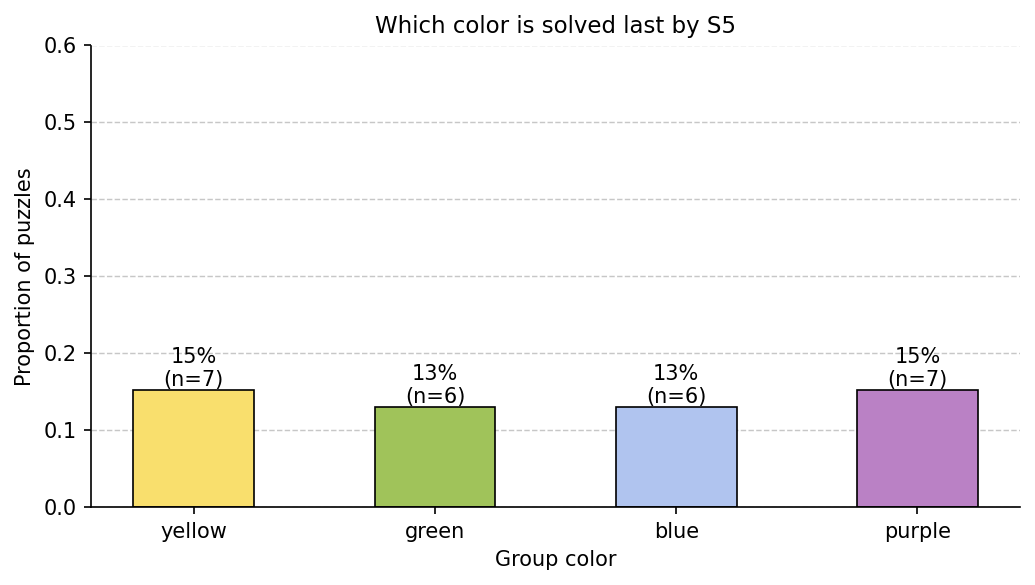

Last solved color distribution:
  yellow: 7 (15.2%)
  green: 6 (13.0%)
  blue: 6 (13.0%)
  purple: 7 (15.2%)


In [44]:
# ── Figure: Which color is solved last by S5 ─────────────────────────
last_solved = order_df[order_df["solve_position"] == order_df.groupby("puzzle_id")["solve_position"].transform("max")]
last_counts = [last_solved[last_solved["color"]==c].shape[0] for c in color_order]
last_rates = [c/46 for c in last_counts]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(color_order, last_rates,
       color=[color_hex[c] for c in color_order],
       edgecolor="black", linewidth=0.8, width=0.5)

for i, (rate, count) in enumerate(zip(last_rates, last_counts)):
    ax.text(i, rate + 0.005, f"{rate:.0%}\n(n={count})",
            ha="center", fontsize=10)

ax.set_xlabel("Group color")
ax.set_ylabel("Proportion of puzzles")
ax.set_title("Which color is solved last by S5", fontsize=11)
ax.set_ylim(0, 0.6)
ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../results/fig_solved_last_by_color.png", dpi=150, bbox_inches="tight")
plt.show()

print("Last solved color distribution:")
for c, count, rate in zip(color_order, last_counts, last_rates):
    print(f"  {c}: {count} ({rate:.1%})")